# Import

In [1]:
import pandas as pd
import numpy as np
import os

# Chemin corrigé — relatif au projet
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.dirname(notebook_dir)
csv_path = os.path.join(project_root, 'data', 'modele_3966_Aug_Dec2025.csv')

df = pd.read_csv(csv_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

print(df.shape)
print(df.index.min(), '->', df.index.max())
df.head()


(3501, 13)
2025-08-08 03:00:00+00:00 -> 2025-12-31 23:00:00+00:00


,P0,P1,P2,humidity,temperature,heure,jour_semaine,periode,P2_lag_1,P2_lag_2,P2_lag_3,P2_lag_24,P2_lag_168
timestamp,,,,,,,,,,,,,
2025-08-08 03:00:00+00:00,22.111431,36.489514,30.930691,84.350000,15.250000,3,Friday,semaine,33.375576,35.820461,38.265346,13.900000,34.6650
2025-08-08 04:00:00+00:00,23.508573,40.748386,32.879269,72.721523,18.704283,4,Friday,semaine,30.930691,33.375576,35.820461,18.950000,31.8325
2025-08-08 05:00:00+00:00,24.905715,45.007257,34.827846,61.093046,22.158567,5,Friday,semaine,32.879269,30.930691,33.375576,24.000000,29.0000
2025-08-08 06:00:00+00:00,24.704000,50.080000,35.366000,51.743310,25.460561,6,Friday,semaine,34.827846,32.879269,30.930691,21.427846,24.0000
2025-08-08 07:00:00+00:00,40.081250,70.162500,54.506250,51.725000,25.150000,7,Friday,semaine,35.366000,34.827846,32.879269,24.236138,23.1000


In [2]:
df.columns

Index(['P0', 'P1', 'P2', 'humidity', 'temperature', 'heure', 'jour_semaine',
       'periode', 'P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24',
       'P2_lag_168'],
      dtype='str')

In [3]:
print(f"Lignes: {len(df)}, Colonnes: {len(df.columns)}")
print(f"Période: {df.index.min()} -> {df.index.max()}")
print(f"Fréquence estimée: {len(df) / ((df.index.max() - df.index.min()).days + 1):.1f} pts/jour")

print("\nVariables:")
for col in df.columns:
    dtype = df[col].dtype
    unique = df[col].nunique()
    print(f"- {col}: {dtype}, {unique} valeurs uniques")

Lignes: 3501, Colonnes: 13
Période: 2025-08-08 03:00:00+00:00 -> 2025-12-31 23:00:00+00:00
Fréquence estimée: 24.0 pts/jour

Variables:
- P0: float64, 3346 valeurs uniques
- P1: float64, 3393 valeurs uniques
- P2: float64, 3379 valeurs uniques
- humidity: float64, 3368 valeurs uniques
- temperature: float64, 3184 valeurs uniques
- heure: int64, 24 valeurs uniques
- jour_semaine: str, 7 valeurs uniques
- periode: str, 2 valeurs uniques
- P2_lag_1: float64, 3379 valeurs uniques
- P2_lag_2: float64, 3379 valeurs uniques
- P2_lag_3: float64, 3379 valeurs uniques
- P2_lag_24: float64, 3378 valeurs uniques
- P2_lag_168: float64, 3371 valeurs uniques


# Split

In [4]:
# Division chronologique (80% train, 20% test)
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

print(f"Train: {train.index.min()} -> {train.index.max()} ({len(train)} pts)")
print(f"Test : {test.index.min()} -> {test.index.max()} ({len(test)} pts)")

Train: 2025-08-08 03:00:00+00:00 -> 2025-12-02 18:00:00+00:00 (2800 pts)
Test : 2025-12-02 19:00:00+00:00 -> 2025-12-31 23:00:00+00:00 (701 pts)


In [5]:
# Baseline: répéter la saisonnalité de 24h
test['pred_baseline_24h'] = test.index.map(
    lambda t: train.loc[t - pd.Timedelta(hours=24), 'P2'] 
    if (t - pd.Timedelta(hours=24)) in train.index 
    else train['P2'].iloc[-24:].mean()
)

# Calcul erreurs
mae = (test['P2'] - test['pred_baseline_24h']).abs().mean()
rmse = ((test['P2'] - test['pred_baseline_24h']) ** 2).mean() ** 0.5

print(f"Baseline 24h - MAE: {mae:.3f}, RMSE: {rmse:.3f}")

Baseline 24h - MAE: 5.634, RMSE: 7.336


# Prophet with temperature and humidity

## Train

In [6]:
# Conversion des timestamps sans fuseau horaire
train_prophet = train.reset_index()[['timestamp', 'P2']].copy()
train_prophet.columns = ['ds', 'y']
train_prophet['ds'] = train_prophet['ds'].dt.tz_localize(None)  # <-- Supprime le fuseau

# Ajout des régresseurs
for col in ['temperature', 'humidity']:
    train_prophet[col] = train[col].values

train_prophet.head()

,ds,y,temperature,humidity
0,2025-08-08 03:00:00,30.930691,15.250000,84.350000
1,2025-08-08 04:00:00,32.879269,18.704283,72.721523
2,2025-08-08 05:00:00,34.827846,22.158567,61.093046
3,2025-08-08 06:00:00,35.366000,25.460561,51.743310
4,2025-08-08 07:00:00,54.506250,25.150000,51.725000


In [7]:
from prophet import Prophet

# Initialisation du modèle avec saisonnalités
model = Prophet(
    yearly_seasonality=False,    # Pas de saisonnalité annuelle (données courtes)
    weekly_seasonality=True,     # Saisonnalité hebdo (168h)
    daily_seasonality=True,      # Saisonnalité quotidienne (24h)
    seasonality_mode='additive'
)

# Ajout des régresseurs
for col in ['temperature', 'humidity']:
    model.add_regressor(col)

# Entraînement
model.fit(train_prophet)
print("✓ Prophet entraîné")

d:\Datascience\Nairobi\.prophet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
23:21:01 - cmdstanpy - INFO - Chain [1] start processing
23:21:01 - cmdstanpy - INFO - Chain [1] done processing


✓ Prophet entraîné


## prediction

In [8]:
# Création du dataframe futur avec régresseurs
future = test.reset_index()[['timestamp']].copy()
future.columns = ['ds']
future['ds'] = future['ds'].dt.tz_localize(None)

for col in ['temperature', 'humidity']:
    future[col] = test[col].values

# Prédiction
forecast = model.predict(future)

# Extraction des prédictions
test['pred_prophet'] = forecast['yhat'].values

# Calcul des erreurs
mae_p = (test['P2'] - test['pred_prophet']).abs().mean()
rmse_p = ((test['P2'] - test['pred_prophet']) ** 2).mean() ** 0.5

print(f"Prophet - MAE: {mae_p:.3f}, RMSE: {rmse_p:.3f}")
print(f"Amélioration vs baseline: {((mae - mae_p) / mae * 100):.1f}%")

Prophet - MAE: 6.133, RMSE: 8.086
Amélioration vs baseline: -8.9%


# Prophet with temperature only

In [9]:
# Conversion des timestamps sans fuseau horaire
train_prophet = train.reset_index()[['timestamp', 'P2']].copy()
train_prophet.columns = ['ds', 'y']
train_prophet['ds'] = train_prophet['ds'].dt.tz_localize(None)  # <-- Supprime le fuseau

# Ajout des régresseurs
for col in ['temperature']:
    train_prophet[col] = train[col].values

train_prophet.head()

,ds,y,temperature
0,2025-08-08 03:00:00,30.930691,15.250000
1,2025-08-08 04:00:00,32.879269,18.704283
2,2025-08-08 05:00:00,34.827846,22.158567
3,2025-08-08 06:00:00,35.366000,25.460561
4,2025-08-08 07:00:00,54.506250,25.150000


In [10]:
# Initialisation du modèle avec saisonnalités
model = Prophet(
    yearly_seasonality=False,    # Pas de saisonnalité annuelle (données courtes)
    weekly_seasonality=True,     # Saisonnalité hebdo (168h)
    daily_seasonality=True,      # Saisonnalité quotidienne (24h)
    seasonality_mode='additive'
)

# Ajout des régresseurs
for col in ['temperature']:
    model.add_regressor(col)

# Entraînement
model.fit(train_prophet)
print("✓ Prophet entraîné")

23:21:02 - cmdstanpy - INFO - Chain [1] start processing
23:21:02 - cmdstanpy - INFO - Chain [1] done processing


✓ Prophet entraîné


In [11]:
# Création du dataframe futur avec régresseurs
future = test.reset_index()[['timestamp']].copy()
future.columns = ['ds']
future['ds'] = future['ds'].dt.tz_localize(None)

for col in ['temperature']:
    future[col] = test[col].values

# Prédiction
forecast = model.predict(future)

# Extraction des prédictions
test['pred_prophet'] = forecast['yhat'].values

# Calcul des erreurs
mae_p = (test['P2'] - test['pred_prophet']).abs().mean()
rmse_p = ((test['P2'] - test['pred_prophet']) ** 2).mean() ** 0.5

print(f"Prophet - MAE: {mae_p:.3f}, RMSE: {rmse_p:.3f}")
print(f"Amélioration vs baseline: {((mae - mae_p) / mae * 100):.1f}%")

Prophet - MAE: 6.274, RMSE: 8.221
Amélioration vs baseline: -11.4%


# Prophet with humidity only

In [12]:
# Conversion des timestamps sans fuseau horaire
train_prophet = train.reset_index()[['timestamp', 'P2']].copy()
train_prophet.columns = ['ds', 'y']
train_prophet['ds'] = train_prophet['ds'].dt.tz_localize(None)  # <-- Supprime le fuseau

# Ajout des régresseurs
for col in ['humidity']:
    train_prophet[col] = train[col].values

train_prophet.head()




,ds,y,humidity
0,2025-08-08 03:00:00,30.930691,84.350000
1,2025-08-08 04:00:00,32.879269,72.721523
2,2025-08-08 05:00:00,34.827846,61.093046
3,2025-08-08 06:00:00,35.366000,51.743310
4,2025-08-08 07:00:00,54.506250,51.725000


In [13]:
# Initialisation du modèle avec saisonnalités
model = Prophet(
    yearly_seasonality=False,    # Pas de saisonnalité annuelle (données courtes)
    weekly_seasonality=True,     # Saisonnalité hebdo (168h)
    daily_seasonality=True,      # Saisonnalité quotidienne (24h)
    seasonality_mode='additive'
)

# Ajout des régresseurs
for col in ['humidity']:
    model.add_regressor(col)

# Entraînement
model.fit(train_prophet)
print("✓ Prophet entraîné")

23:21:02 - cmdstanpy - INFO - Chain [1] start processing
23:21:03 - cmdstanpy - INFO - Chain [1] done processing


✓ Prophet entraîné


In [14]:
# Création du dataframe futur avec régresseurs
future = test.reset_index()[['timestamp']].copy()
future.columns = ['ds']
future['ds'] = future['ds'].dt.tz_localize(None)

for col in ['humidity']:
    future[col] = test[col].values

# Prédiction
forecast = model.predict(future)

# Extraction des prédictions
test['pred_prophet'] = forecast['yhat'].values

# Calcul des erreurs
mae_p = (test['P2'] - test['pred_prophet']).abs().mean()
rmse_p = ((test['P2'] - test['pred_prophet']) ** 2).mean() ** 0.5

print(f"Prophet - MAE: {mae_p:.3f}, RMSE: {rmse_p:.3f}")
print(f"Amélioration vs baseline: {((mae - mae_p) / mae * 100):.1f}%")

Prophet - MAE: 6.139, RMSE: 8.093
Amélioration vs baseline: -9.0%


# Xgboost

In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Features : seulement les lags de P2
lag_features = ['P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24', 'P2_lag_168']

X_train = train[lag_features]
y_train = train['P2']
X_test = test[lag_features]
y_test = test['P2']

# Modèle simple
model_xgb = XGBRegressor(n_estimators=100, max_depth=3, random_state=42)
model_xgb.fit(X_train, y_train)

# Prédiction
test['pred_xgb_lags'] = model_xgb.predict(X_test)

# Évaluation
mae_xgb = mean_absolute_error(y_test, test['pred_xgb_lags'])
improvement = ((mae - mae_xgb) / mae * 100)

print(f"XGBoost (lags uniquement) - MAE: {mae_xgb:.3f}")
print(f"Amélioration vs baseline 24h: {improvement:.1f}%")

XGBoost (lags uniquement) - MAE: 3.693
Amélioration vs baseline 24h: 34.5%


# Xgboost with all features 

In [16]:
# Features autorisées (sans P0, P1 qui sont des cibles)
features = ['humidity', 'temperature', 'heure', 'jour_semaine', 'periode',
            'P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24', 'P2_lag_168']

X_train = train[features].copy()
X_test = test[features].copy()

# Encodage simple des catégorielles
for col in ['jour_semaine', 'periode']:
    if X_train[col].dtype == 'object' or X_train[col].dtype == 'str':
        # Encodage numérique simple et conversion en int
        X_train[col] = pd.factorize(X_train[col])[0].astype(int)
        X_test[col] = pd.factorize(X_test[col])[0].astype(int)

# Conversion explicite de 'heure' en int si nécessaire
if X_train['heure'].dtype == 'object':
    X_train['heure'] = X_train['heure'].astype(int)
    X_test['heure'] = X_test['heure'].astype(int)

print("Features préparées:", X_train.shape)
print("Dtypes:", X_train.dtypes.to_dict())


Features préparées: (2800, 10)
Dtypes: {'humidity': dtype('float64'), 'temperature': dtype('float64'), 'heure': dtype('int64'), 'jour_semaine': dtype('int64'), 'periode': dtype('int64'), 'P2_lag_1': dtype('float64'), 'P2_lag_2': dtype('float64'), 'P2_lag_3': dtype('float64'), 'P2_lag_24': dtype('float64'), 'P2_lag_168': dtype('float64')}


In [17]:
model_xgb_feat = XGBRegressor(n_estimators=150, max_depth=4, random_state=42)
model_xgb_feat.fit(X_train, y_train)

test['pred_xgb_feat'] = model_xgb_feat.predict(X_test)
mae_xgb_feat = mean_absolute_error(y_test, test['pred_xgb_feat'])

print(f"XGBoost (sans P0/P1) - MAE: {mae_xgb_feat:.3f}")
print(f"vs Baseline 24h: {((mae - mae_xgb_feat) / mae * 100):.1f}% d'amélioration")
print(f"vs XGBoost lags seulement: {((mae_xgb - mae_xgb_feat) / mae_xgb * 100):.1f}%")

XGBoost (sans P0/P1) - MAE: 3.715
vs Baseline 24h: 34.1% d'amélioration
vs XGBoost lags seulement: -0.6%


# Bilan

-  Le modèle Prophet est 8.9% moins bon que votre simple baseline de saisonnalité 24h lorsqu'on lui  
ajoute les variables "humidity" et "temperature". 
- XGBoost avec seulement les lags réduit l'erreur de 34.5% par rapport à la baseline. C'est très significatif.  


**Conclusion**:  
- ✅ Meilleur modèle : XGBoost avec lags P2 + features temporelles (heure, jour_semaine)
- ✅ Les 5 lags contiennent l'information prédictive pour le one-step-ahead
- ✅ Les features temporelles (heure, jour) sont cruciales pour la **prédiction récursive multi-step** (dashboard)
- ❌ Variables externes : temperature, humidity n'apportent pas de valeur ajoutée pour prédire P2

> ⚠️ **Important** : La MAE ci-dessus évalue du "one-step-ahead" (chaque point utilise les VRAIS lags).  
> Dans le dashboard, la prédiction est **récursive** (chaque prédiction devient input du pas suivant).  
> Les features temporelles permettent de maintenir les cycles jour/nuit dans la prédiction récursive.

# Finne-Tunning

Importance des features (lags seulement):
      feature  importance
0    P2_lag_1    0.592745
3   P2_lag_24    0.206387
4  P2_lag_168    0.094011
1    P2_lag_2    0.076871
2    P2_lag_3    0.029986


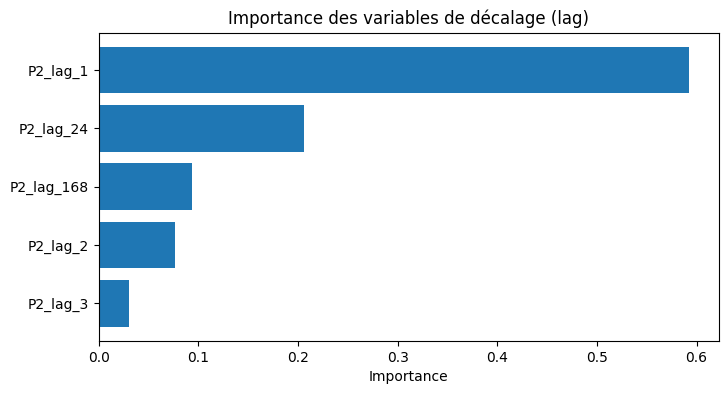

In [18]:
import matplotlib.pyplot as plt
# Importance des variables
importance = pd.DataFrame({
    'feature': ['P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24', 'P2_lag_168'],
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("Importance des features (lags seulement):")
print(importance)

# Visualisation
plt.figure(figsize=(8, 4))
plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Importance')
plt.title('Importance des variables de décalage (lag)')
plt.gca().invert_yaxis()
plt.show()

In [19]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Features : lags + features temporelles (connues à l'avance pour la prédiction récursive)
lag_features = ['P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24', 'P2_lag_168']

# Encoder jour_semaine en numérique
DAY_MAP = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
           'Friday': 4, 'Saturday': 5, 'Sunday': 6}

train['jour_semaine_num'] = train['jour_semaine'].map(DAY_MAP).fillna(0).astype(int)
test['jour_semaine_num']  = test['jour_semaine'].map(DAY_MAP).fillna(0).astype(int)
train['heure'] = train['heure'].astype(int)
test['heure']  = test['heure'].astype(int)

temporal_features = ['heure', 'jour_semaine_num']
all_features = lag_features + temporal_features

X_train_lags = train[all_features]
X_test_lags  = test[all_features]

print(f"Features utilisées ({len(all_features)}): {all_features}")

# Validation croisée temporelle (pas de shuffle)
tscv = TimeSeriesSplit(n_splits=3)

# Grille de paramètres réduite
param_grid = {
    'max_depth': [3, 4],
    'n_estimators': [80, 120],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Recherche
grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_lags, y_train)

# Résultats
print(f"\nMeilleurs paramètres: {grid.best_params_}")
print(f"Meilleur score (MAE négatif): {grid.best_score_:.3f}")

Features utilisées (7): ['P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24', 'P2_lag_168', 'heure', 'jour_semaine_num']
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Meilleurs paramètres: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 80, 'subsample': 0.8}
Meilleur score (MAE négatif): -4.205


In [20]:
# Modèle avec meilleurs paramètres
best_model = grid.best_estimator_

# Prédiction sur le test
test['pred_xgb_tuned'] = best_model.predict(X_test_lags)

# Évaluation
mae_tuned = mean_absolute_error(y_test, test['pred_xgb_tuned'])
improvement_vs_untuned = ((mae_xgb - mae_tuned) / mae_xgb * 100)

print(f"XGBoost fine-tuned - MAE: {mae_tuned:.3f}")
print(f"Amélioration vs XGBount non-optimisé: {improvement_vs_untuned:.1f}%")

# Comparaison finale
print(f"\n=== RÉCAPITULATIF MAE ===")
print(f"Baseline 24h: {mae:.3f}")
print(f"XGBoost simple: {mae_xgb:.3f} (amélioration: {((mae - mae_xgb)/mae*100):.1f}%)")
print(f"XGBoost fine-tuned: {mae_tuned:.3f} (amélioration: {((mae - mae_tuned)/mae*100):.1f}%)")

XGBoost fine-tuned - MAE: 3.434
Amélioration vs XGBount non-optimisé: 7.0%

=== RÉCAPITULATIF MAE ===
Baseline 24h: 5.634
XGBoost simple: 3.693 (amélioration: 34.5%)
XGBoost fine-tuned: 3.434 (amélioration: 39.0%)


# Validation sur la derniere semaine

In [21]:
# Validation sur les dernières données
last_week = test.iloc[-168:]  # Dernière semaine
mae_final = mean_absolute_error(last_week['P2'], last_week['pred_xgb_tuned'])
print(f"MAE sur dernière semaine: {mae_final:.3f}")

MAE sur dernière semaine: 4.396


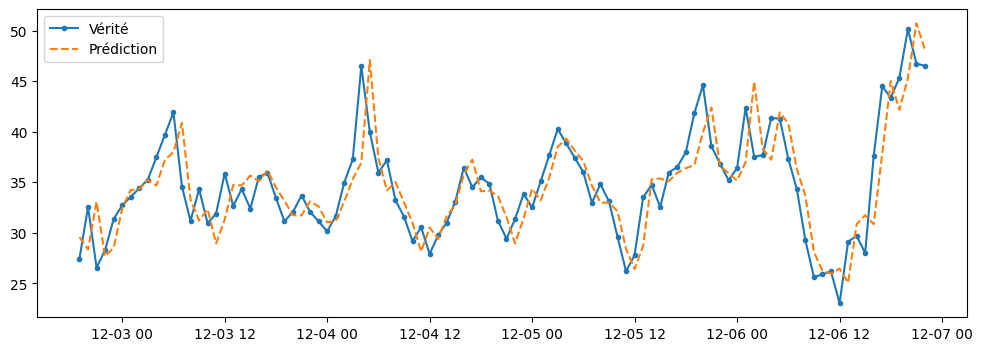

In [22]:
# Visualiser prédictions vs réalité
plt.figure(figsize=(12, 4))
plt.plot(test.index[:100], test['P2'].iloc[:100], label='Vérité', marker='.')
plt.plot(test.index[:100], test['pred_xgb_tuned'].iloc[:100], label='Prédiction', linestyle='--')
plt.legend()
plt.show()

In [23]:
import joblib
import os

# Chemins de sauvegarde
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.dirname(notebook_dir)
models_dir = os.path.join(project_root, 'models')
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, 'xgb_pm25.joblib')
metrics_path = os.path.join(models_dir, 'metrics.joblib')

# Récupération du meilleur modèle
best_model = grid.best_estimator_

# Calcul de l'écart-type des résidus (pour intervalle de confiance)
residuals = y_test.values - test['pred_xgb_tuned'].values
residual_std = float(np.std(residuals))

# Features utilisées (lags + temporelles)
all_features = ['P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24', 'P2_lag_168',
                'heure', 'jour_semaine_num']

# Métriques à sauvegarder
metrics = {
    'mae': mae_tuned,
    'residual_std': residual_std,
    'best_params': grid.best_params_,
    'importance': dict(zip(all_features, best_model.feature_importances_)),
    'test_actual': y_test.values.tolist()[:200],
    'test_predicted': test['pred_xgb_tuned'].values.tolist()[:200],
}

# Sauvegarde
joblib.dump(best_model, model_path)
joblib.dump(metrics, metrics_path)

print(f"✅ Modèle sauvegardé : {model_path}")
print(f"✅ Métriques sauvegardées : {metrics_path}")
print(f"\n📊 Résumé :")
print(f"   MAE           : {mae_tuned:.2f} µg/m³")
print(f"   Écart-type    : {residual_std:.2f}")
print(f"   Meilleurs params : {grid.best_params_}")
print(f"   Features ({len(all_features)}): {all_features}")
print(f"   Feature importance : {metrics['importance']}")

✅ Modèle sauvegardé : d:\Datascience\Nairobi\models\xgb_pm25.joblib
✅ Métriques sauvegardées : d:\Datascience\Nairobi\models\metrics.joblib

📊 Résumé :
   MAE           : 3.43 µg/m³
   Écart-type    : 5.04
   Meilleurs params : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 80, 'subsample': 0.8}
   Features (7): ['P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24', 'P2_lag_168', 'heure', 'jour_semaine_num']
   Feature importance : {'P2_lag_1': np.float32(0.43889198), 'P2_lag_2': np.float32(0.06281807), 'P2_lag_3': np.float32(0.072110355), 'P2_lag_24': np.float32(0.2530222), 'P2_lag_168': np.float32(0.098504715), 'heure': np.float32(0.046739496), 'jour_semaine_num': np.float32(0.027913224)}


# 💾 Sauvegarde du modèle optimisé + Évaluation récursive

> Le test "one-step-ahead" utilise les VRAIS lags → MAE optimiste.  
> L'évaluation ci-dessous simule la **prédiction récursive** (comme dans le dashboard) pour mesurer la vraie performance multi-step.

═══ COMPARAISON DES ÉVALUATIONS ═══
MAE one-step-ahead (vrais lags)  : 3.43 µg/m³
MAE récursive (168h, comme dash) : 4.11 µg/m³
Ratio récursif/one-step          : 1.2x



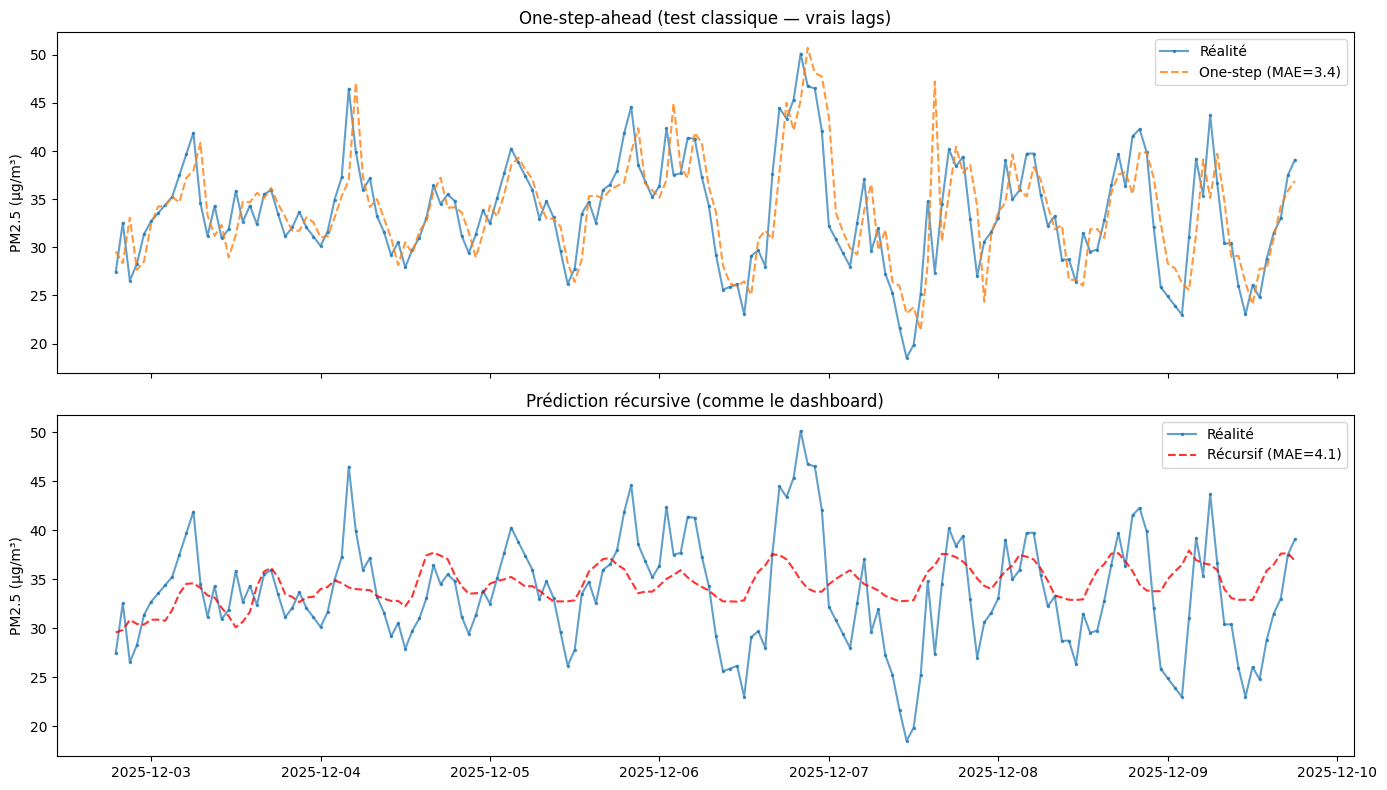


✅ Avec les features temporelles (heure, jour), le modèle maintient
   les cycles jour/nuit même en mode récursif.


In [25]:
# ══════════════════════════════════════════════════════════════
# Évaluation RÉCURSIVE (multi-step) — simule le dashboard
# ══════════════════════════════════════════════════════════════

def recursive_prediction(model, history_df, test_df, all_features):
    """Simule la prédiction récursive sur le jeu de test (comme le dashboard)."""
    p2_vals = list(history_df['P2'].values)
    timestamps = list(history_df.index)
    
    predictions = []
    
    for i in range(len(test_df)):
        real_ts = test_df.index[i]
        
        feats = {
            'P2_lag_1':   p2_vals[-1],
            'P2_lag_2':   p2_vals[-2],
            'P2_lag_3':   p2_vals[-3],
            'P2_lag_24':  p2_vals[-24]  if len(p2_vals) >= 24  else p2_vals[0],
            'P2_lag_168': p2_vals[-168] if len(p2_vals) >= 168 else p2_vals[0],
            'heure':            real_ts.hour,
            'jour_semaine_num': real_ts.dayofweek,
        }
        
        pred = float(model.predict(pd.DataFrame([feats]))[0])
        pred = max(0, pred)
        predictions.append(pred)
        
        p2_vals.append(pred)
        timestamps.append(real_ts)
    
    return np.array(predictions)

# Prédiction récursive sur la première semaine de test (168 pts)
n_eval = 168
history_for_eval = train.tail(200)
test_subset = test.iloc[:n_eval]

preds_recursive = recursive_prediction(best_model, history_for_eval, test_subset, all_features)
actual_subset = test_subset['P2'].values

mae_recursive = np.mean(np.abs(actual_subset - preds_recursive))
mae_onestep = mean_absolute_error(y_test, test['pred_xgb_tuned'])

print("═══ COMPARAISON DES ÉVALUATIONS ═══")
print(f"MAE one-step-ahead (vrais lags)  : {mae_onestep:.2f} µg/m³")
print(f"MAE récursive (168h, comme dash) : {mae_recursive:.2f} µg/m³")
print(f"Ratio récursif/one-step          : {mae_recursive/mae_onestep:.1f}x")
print()

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top : one-step-ahead
axes[0].plot(test_subset.index, actual_subset, label='Réalité', marker='.', markersize=3, alpha=0.7)
axes[0].plot(test_subset.index, test['pred_xgb_tuned'].iloc[:n_eval], 
             label=f'One-step (MAE={mae_onestep:.1f})', linestyle='--', alpha=0.8)
axes[0].set_title('One-step-ahead (test classique — vrais lags)')
axes[0].legend()
axes[0].set_ylabel('PM2.5 (µg/m³)')

# Bottom : recursive (comme le dashboard)
axes[1].plot(test_subset.index, actual_subset, label='Réalité', marker='.', markersize=3, alpha=0.7)
axes[1].plot(test_subset.index, preds_recursive, 
             label=f'Récursif (MAE={mae_recursive:.1f})', linestyle='--', color='red', alpha=0.8)
axes[1].set_title('Prédiction récursive (comme le dashboard)')
axes[1].legend()
axes[1].set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()

print("\n✅ Avec les features temporelles (heure, jour), le modèle maintient")
print("   les cycles jour/nuit même en mode récursif.")